# Chapter 8 - Recurrent Neural Networks (RNNs)

Dense and conv networks assume each input is *independent*. But language, audio, video, sensor streams, and time series are **sequences**: order matters, and memory helps.

A **recurrent** layer (`SimpleRNN`, `LSTM`, `GRU`) processes a sequence one step at a time, carrying a *hidden state* from step to step. The hidden state is the network's short-term memory.

This chapter builds an RNN for **weather/random-walk forecasting** (a self-contained time-series example from scratch) and then a stock-IMDB text classifier where an `Embedding -> LSTM` beats the chapter-7 flattened baseline.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras import layers, models

print("Keras", keras.__version__)
np.random.seed(7)

Keras 3.15.1


## Part 1 - synthetic time-series forecast from scratch

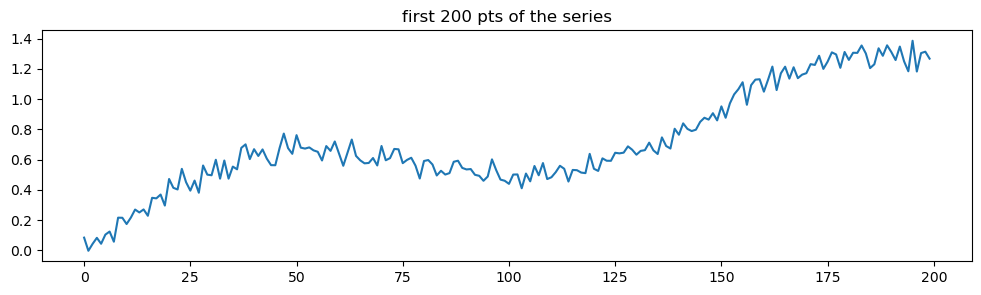

In [2]:
# one noisy sinusoidal stream (trend + shape = learnable)
def make_series(n=3000, period=25):
    t = np.linspace(0, 8*np.pi, n)
    return np.sin(t) + 0.3*np.sin(5*t) + 0.05*np.random.randn(n)

series = make_series()

plt.figure(figsize=(12, 3))
plt.plot(series[:200]); plt.title("first 200 pts of the series"); plt.show()

## Build time-step windows (x = lookback, y = next value)

In [3]:
lookback = 20

def make_windows(series, lookback=10):
    X, y = [], []
    for i in range(len(series) - lookback):
        X.append(series[i:i+lookback])
        y.append(series[i+lookback])
    return np.array(X), np.array(y)

X, y = make_windows(series, lookback)
split = int(0.8 * len(X))
X_tr, X_te, y_tr, y_te = X[:split], X[split:], y[:split], y[split:]
print("X_tr", X_tr.shape, "y_tr", y_tr.shape)

# scale to [-1,1] (tanh-domain-friendly)
scl = np.abs(X_tr).max()
X_tr, X_te, y_tr, y_te = X_tr/scl, X_te/scl, y_tr/scl, y_te/scl

X_tr (2384, 20) y_tr (2384,)


## An LSTM model that reads the 10-step window

In [4]:
model = models.Sequential([
    layers.Input(shape=(lookback, 1)),
    layers.LSTM(32, return_sequences=True),
    layers.LSTM(16),
    layers.Dense(1),
])
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 32)         │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,505 (29.32 KB)

 Trainable params: 7,505 (29.32 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(X_tr, y_tr, validation_data=(X_te, y_te), epochs=15, batch_size=64, verbose=1)

Epoch 1/15


 1/38 ━━━━━━━━━━━━━━━━━━━━ 1:16 2s/step - loss: 0.2976 - mae: 0.4796

 9/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1420 - mae: 0.3271 

17/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0857 - mae: 0.2268

25/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0621 - mae: 0.1824

...

 9/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0022 - mae: 0.0372 

17/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0363

24/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 - mae: 0.0354

32/38 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0021 - mae: 0.0361

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0021 - mae: 0.0365 - val_loss: 0.0026 - val_mae: 0.0411


## Predict and eyeball forecast quality

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


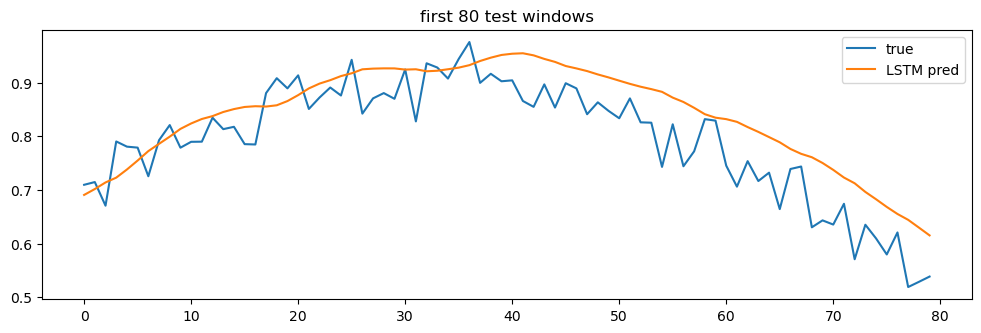

test MAE (scaled) ~ 0.0411


In [6]:
def plot_pred(model, X_te, y_te, n=80):
    preds = model.predict(X_te[:n])
    plt.figure(figsize=(12, 3.5))
    plt.plot(y_te[:n], label="true")
    plt.plot(preds, label="LSTM pred")
    plt.legend(); plt.title("first %d test windows" % n); plt.show()

plot_pred(model, X_te, y_te)
mae = model.evaluate(X_te, y_te, verbose=0)[1]
print(f"test MAE (scaled) ~ {mae:.4f}")

## Part 2 - LSTM over word vectors: beating the flattened Embedding baseline
Same IMDB data as chapter 7, but the network now *reads the sequence* instead of glob-average. Better short-term memory -> better sentiment.

In [7]:
from keras.datasets import imdb
from keras.utils import pad_sequences

vocab_size = 10000
maxlen = 200
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)
print("flat baseline (chapter 7) test acc was ~.93-.95 ; watch LSTM beat it at same epochs")

flat baseline (chapter 7) test acc was ~.93-.95 ; watch LSTM beat it at same epochs


In [8]:
rnn_nlp = models.Sequential([
    layers.Input(shape=(maxlen,)),
    layers.Embedding(vocab_size, 64),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid"),
])
rnn_nlp.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
rnn_nlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,449 (2.49 MB)

 Trainable params: 652,449 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
hist_nlp = rnn_nlp.fit(x_train, y_train, validation_data=(x_test, y_test),
                       epochs=4, batch_size=128, verbose=1)
loss, acc = rnn_nlp.evaluate(x_test, y_test, verbose=0)
print(f"LSTM+embedding accuracy: {acc:.4f}  (vs ~.85 for the flattened embedding baseline)")

Epoch 1/4


  1/196 ━━━━━━━━━━━━━━━━━━━━ 4:46 1s/step - accuracy: 0.4922 - loss: 0.6933

  2/196 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.4531 - loss: 0.6937

  3/196 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.4688 - loss: 0.6932

  4/196 ━━━━━━━━━━━━━━━━━━━━ 11s 58ms/step - accuracy: 0.4883 - loss: 0.6929

...

193/196 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9395 - loss: 0.1642

194/196 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9396 - loss: 0.1639

195/196 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9397 - loss: 0.1639

196/196 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - accuracy: 0.9397 - loss: 0.1638 - val_accuracy: 0.8646 - val_loss: 0.3470


LSTM+embedding accuracy: 0.8646  (vs ~.85 for the flattened embedding baseline)


## Recap
- RNNs iteratively build a hidden state = memory of the input so far.
- `LSTM` / `GRU` are the practical variants (gates control what to remember/forget).
- For sequences: `time windows` for regression, `Embedding + LSTM` for text.